
=== En iyi Y-Model Parametreleri (VAL) ===
RF : {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1} | VAL_MAE=56.94
XGB: {'n_estimators': 700, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_lambda': 2.0, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'} | VAL_MAE=47.10

=== Kıyas Tablosu — Full (2025-01..07) ve Short3 (2025-01..03) ===
Horizon        Exog Y-Model   MAE  RMSE  MAPE
   Full    Ensemble      RF 62.07 73.56 55.49
   Full    Ensemble     XGB 63.79 71.44 54.36
   Full  ML-Exog RF      RF 56.09 62.83 47.93
   Full  ML-Exog RF     XGB 62.90 69.86 52.52
   Full ML-Exog XGB      RF 53.64 63.83 47.52
   Full ML-Exog XGB     XGB 55.48 62.51 47.33
 Short3    Ensemble      RF 47.07 57.32 40.87
 Short3    Ensemble     XGB 52.21 64.25 45.19
 Short3  ML-Exog RF      RF 41.94 44.10 32.98
 Short3  ML-Exog RF     XGB 37.30 41.43 30.69
 Short3 ML-Exog XGB      RF 36.63 46.62 3

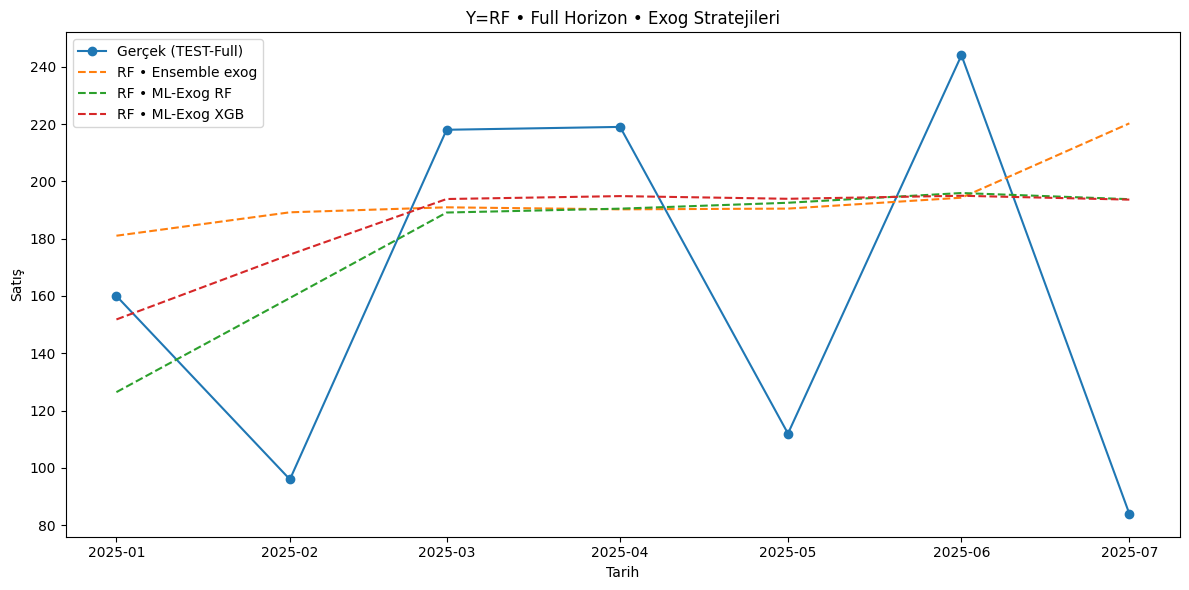

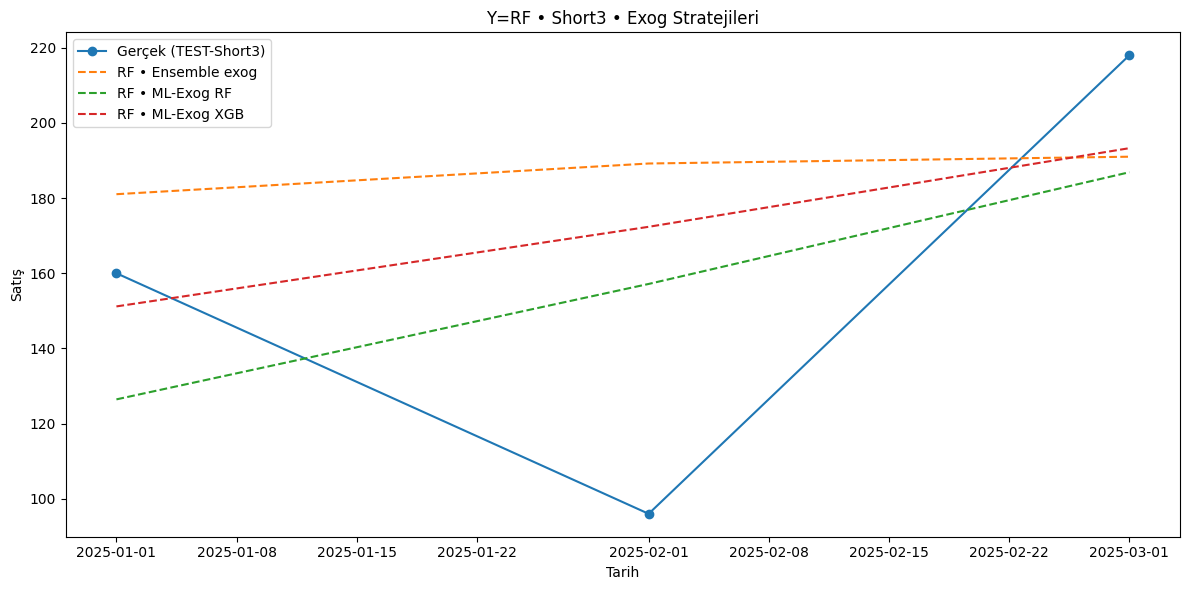


[MODEL SAVED] En iyi Y modeli: RF → serialized_models/best_y_model_rf_full.joblib


In [9]:
# ==============================================================
# Y-Model (RF & XGB) + Exog Ensemble (Prophet+SARIMA+ETS+RF-Exog+XGB-Exog)
# - Uyarılar/Loglar bastırıldı
# - Orders/Stock için RF ve XGB (ML-Exog) hiperparametre optimizasyonu eklendi
# - Inverse-MAE ağırlıklı ensemble; zayıf yöntemler MAE eşiği ile dışlanır
# - Kıyas: Full (2025-01..07) ve Short3 (2025-01..03)
# - En iyi Y modeli (Full MAE) joblib ile serileştirilir
# ==============================================================

# ------------------ Warnings & Logging OFF ------------------
import warnings, logging
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed to converge")
warnings.filterwarnings("ignore", message="Optimization failed to converge")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("statsmodels").setLevel(logging.ERROR)

# ------------------ Imports ------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import joblib
import os

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")
TEST_END_SHORT = pd.Timestamp("2025-03-01")  # 3 aylık kısa ufuk

RANDOM_STATE = 42
EXOG_VAL_H   = 6                 # exog yöntemleri için backtest ufku (ay)
EPS_PROPHET  = 0.00              # inverse-MAE'de Prophet'e ekstra bias (istersen >0 gir)
MAE_REL_THRESH = 2.0             # ensemble'da: en iyi MAE'nin 2x'tan kötüler dışlanır
MODEL_DUMP_DIR = "serialized_models"
os.makedirs(MODEL_DUMP_DIR, exist_ok=True)

FEATURES_Y = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

EXOG_FEATURES = ["lag1","lag3","month","year"]  # ML-Exog için sade set

# ------------------ Utils ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def ensure_ms_freq(df):
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def add_calendar(df):
    d = df.copy()
    d["year"]  = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def rolling_impute(s, causal=False):
    x = pd.to_numeric(s, errors="coerce")
    if causal:
        x = x.ffill()
        x = x.rolling(window=3, min_periods=1).mean()
        x = x.bfill()
    else:
        roll = x.rolling(window=3, center=True, min_periods=1).mean()
        x = x.where(~x.isna(), roll).ffill().bfill()
    return x

def smooth_causal_ma(s, window=3):
    x = pd.to_numeric(s, errors="coerce").ffill()
    return x.rolling(window=window, min_periods=1).mean().bfill()

def winsorize_series(s, lower_q=0.05, upper_q=0.95):
    x = pd.to_numeric(s, errors="coerce")
    lo = np.nanpercentile(x, lower_q*100)
    hi = np.nanpercentile(x, upper_q*100)
    return x.clip(lo, hi)

def nonneg(s):
    return pd.to_numeric(s, errors="coerce").clip(lower=0.0)

def build_lags_y(df):
    d = df.copy()
    if "orders" in d.columns and "stock" in d.columns:
        d["orders_ratio"] = d["orders"] / d["stock"].replace(0, np.nan)
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def prep_features_y(df_in, causal=False):
    d = add_calendar(df_in)
    d = build_lags_y(d)
    for col in ["orders","stock"]:
        if col in d.columns:
            d[col] = rolling_impute(d[col], causal=causal)
    for col in ["orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").ffill().bfill().fillna(0.0)
    for c in FEATURES_Y:
        if c not in d.columns:
            d[c] = 0.0
    return d.replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------ Univariate exog (Prophet/SARIMA/ETS) ------------------
def fit_prophet(train_df, value_col):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    m.fit(train_df.rename(columns={value_col:"y"}))
    return m

def forecast_prophet(model, steps):
    fut = model.make_future_dataframe(periods=steps, freq="MS")
    fc  = model.predict(fut)[["ds","yhat"]].tail(steps)
    return fc.rename(columns={"yhat":"yhat"})

def sarima_fit_best(y, p_range=(0,3), q_range=(0,3), P_range=(0,1), Q_range=(0,1)):
    best, best_aic = None, np.inf
    for p in range(p_range[0], p_range[1]+1):
        for q in range(q_range[0], q_range[1]+1):
            for P in range(P_range[0], P_range[1]+1):
                for Q in range(Q_range[0], Q_range[1]+1):
                    try:
                        r = SARIMAX(y, order=(p,1,q), seasonal_order=(P,1,Q,12),
                                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                        if r.aic < best_aic:
                            best_aic = r.aic
                            best = ((p,1,q),(P,1,Q,12))
                    except Exception:
                        pass
    return best

def fit_sarima(train_df, value_col):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    best = sarima_fit_best(y)
    if best is None:
        return None
    return SARIMAX(y, order=best[0], seasonal_order=best[1],
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def forecast_sarima(model, steps, future_idx):
    pred = model.get_forecast(steps=steps).predicted_mean
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

def fit_ets(train_df, value_col):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    best, best_aic, best_model = None, np.inf, None
    for trend in ["add", "mul", None]:
        for seasonal in ["add", "mul", None]:
            try:
                for damped in [True, False]:
                    if seasonal is None:
                        model = ExponentialSmoothing(y, trend=trend, seasonal=None, damped_trend=damped).fit(optimized=True)
                    else:
                        model = ExponentialSmoothing(y, trend=trend, seasonal=seasonal, seasonal_periods=12,
                                                     damped_trend=damped).fit(optimized=True)
                    aic = getattr(model, "aic", np.inf)
                    if aic < best_aic:
                        best_aic, best, best_model = aic, (trend, seasonal, damped), model
            except Exception:
                continue
    if best_model is None:
        best_model = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
    return best_model

def forecast_ets(model, steps, future_idx):
    pred = model.forecast(steps)
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

# ------------------ ML-Exog: feature çerçevesi ------------------
def make_exog_feature_frame(df_var, var_col):
    d = df_var[["ds", var_col]].sort_values("ds").copy()
    d["lag1"] = d[var_col].shift(1)
    d["lag3"] = d[var_col].shift(3)
    d["month"] = d["ds"].dt.month
    d["year"]  = d["ds"].dt.year
    return d

# ------------------ ML-Exog: HP optimizasyonu ------------------
def optimize_exog_rf(df_var, var_col, cutoff, val_h=EXOG_VAL_H):
    """cutoff öncesini train; son val_h ayı val. Walk-forward recursive değil; tek-adım validasyon.
       Hız/istikrar için grid küçük tutuldu."""
    d = make_exog_feature_frame(df_var[df_var["ds"] < cutoff], var_col).dropna()
    if len(d) < val_h + 12:
        # veri yetersizse sabit param
        params = dict(n_estimators=400, max_depth=8, min_samples_split=2, min_samples_leaf=1,
                      random_state=RANDOM_STATE, n_jobs=-1)
        mdl = RandomForestRegressor(**params).fit(d[EXOG_FEATURES], d[var_col])
        return mdl, params, np.nan

    cut_ts = d["ds"].max() - pd.DateOffset(months=val_h-1)
    tr = d[d["ds"] < cut_ts]; va = d[d["ds"] >= cut_ts]
    Xtr, ytr = tr[EXOG_FEATURES], tr[var_col]
    Xva, yva = va[EXOG_FEATURES], va[var_col]

    grid = [
        dict(n_estimators=300, max_depth=6,  min_samples_leaf=1),
        dict(n_estimators=500, max_depth=8,  min_samples_leaf=1),
        dict(n_estimators=800, max_depth=10, min_samples_leaf=2),
    ]
    best, best_mae = None, np.inf
    for g in grid:
        params = dict(random_state=RANDOM_STATE, n_jobs=-1,
                      n_estimators=g["n_estimators"], max_depth=g["max_depth"],
                      min_samples_split=2, min_samples_leaf=g["min_samples_leaf"])
        m = RandomForestRegressor(**params).fit(Xtr, ytr)
        pred = m.predict(Xva)
        mae = mae_rmse_mape(yva, pred)[0]
        if mae < best_mae:
            best_mae, best = mae, (params, m)
    return best[1], best[0], best_mae

def optimize_exog_xgb(df_var, var_col, cutoff, val_h=EXOG_VAL_H):
    d = make_exog_feature_frame(df_var[df_var["ds"] < cutoff], var_col).dropna()
    if len(d) < val_h + 12:
        params = dict(n_estimators=500, learning_rate=0.08, max_depth=3,
                      subsample=0.9, colsample_bytree=0.9, reg_lambda=1.2,
                      random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")
        mdl = XGBRegressor(**params).fit(d[EXOG_FEATURES].to_numpy(), d[var_col].to_numpy(), verbose=False)
        return mdl, params, np.nan

    cut_ts = d["ds"].max() - pd.DateOffset(months=val_h-1)
    tr = d[d["ds"] < cut_ts]; va = d[d["ds"] >= cut_ts]
    Xtr, ytr = tr[EXOG_FEATURES].to_numpy(), tr[var_col].to_numpy()
    Xva, yva = va[EXOG_FEATURES].to_numpy(), va[var_col].to_numpy()

    grid = [
        dict(n_estimators=400, learning_rate=0.08, max_depth=3, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0),
        dict(n_estimators=600, learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.5),
        dict(n_estimators=800, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0),
    ]
    best, best_mae = None, np.inf
    for g in grid:
        params = dict(**g, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")
        m = XGBRegressor(**params)
        m.fit(Xtr, ytr, verbose=False)
        pred = m.predict(Xva)
        mae = mae_rmse_mape(yva, pred)[0]
        if mae < best_mae:
            best_mae, best = mae, (params, m)
    return best[1], best[0], best_mae

# ------------------ ML-Exog: recursive forecast ------------------
def recursive_forecast_exog(model, hist_df, var_col, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    full = hist_df[["ds", var_col]].sort_values("ds").copy()
    out = []
    for ds in future_idx:
        tmp = make_exog_feature_frame(full, var_col)
        row = tmp[tmp["ds"] == ds][EXOG_FEATURES]
        if row.empty:
            row = pd.DataFrame({
                "lag1": [full[var_col].iloc[-1] if len(full) else 0.0],
                "lag3": [full[var_col].iloc[-3] if len(full) >= 3 else (full[var_col].iloc[-1] if len(full) else 0.0)],
                "month":[ds.month], "year":[ds.year]
            })
        x = row.to_numpy()
        yhat = float(model.predict(x)[0])
        out.append({"ds": ds, var_col: max(0.0, yhat)})
        full = pd.concat([full, pd.DataFrame({"ds":[ds], var_col:[yhat]})], ignore_index=True)
    return pd.DataFrame(out)

# ------------------ Backtest MAE Helpers ------------------
def backtest_mae_univariate(series_df, value_col, method, val_h=EXOG_VAL_H):
    s_full = series_df[["ds", value_col]].dropna().sort_values("ds")
    s = s_full[s_full["ds"] < TEST_START]
    if len(s) < val_h + 6:
        return np.inf
    cut = s["ds"].max() - pd.DateOffset(months=val_h-1)
    train = s[s["ds"] < cut]
    val   = s[s["ds"] >= cut]
    steps = len(val)
    try:
        if method == "prophet":
            m = fit_prophet(train, value_col)
            yhat = forecast_prophet(m, steps)["yhat"].values
        elif method == "sarima":
            m = fit_sarima(train, value_col)
            if m is None: return np.inf
            yhat = forecast_sarima(m, steps, val["ds"].values)["yhat"].values
        else:
            m = fit_ets(train, value_col)
            yhat = forecast_ets(m, steps, val["ds"].values)["yhat"].values
    except Exception:
        return np.inf
    return mae_rmse_mape(val[value_col].values, yhat)[0]
'''
def backtest_mae_ml_exog(df_all, var_col, learner="rf", val_h=EXOG_VAL_H):
    """Validation döneminde (cutoff öncesi son val_h ay) recursive ML-Exog tahminine göre MAE."""
    s_all = df_all[["ds", var_col]].dropna().sort_values("ds")
    s = s_all[s_all["ds"] < TEST_START]
    if len(s) < val_h + 12:
        return np.inf, None
    steps = val_h
    val_start = s["ds"].max() - pd.DateOffset(months=val_h-1)
    # modeli cutoff=val_start üzerinde eğit, val ufkunda recursive tahmin üret
    if learner == "rf":
        mdl, params, _ = optimize_exog_rf(df_all[["ds", var_col]], var_col, cutoff=val_start, val_h=val_h)
    else:
        mdl, params, _ = optimize_exog_xgb(df_all[["ds", var_col]], var_col, cutoff=val_start, val_h=val_h)
    fc = recursive_forecast_exog(mdl, s_all[s_all["ds"] < val_start][["ds", var_col]].copy(),
                                 var_col, start_ds=val_start, end_ds=s["ds"].max())
    # karşılaştır
    truth = s_all[s_all["ds"].between(val_start, s["ds"].max())][["ds", var_col]]
    merged = truth.merge(fc, on="ds", suffixes=("_true", "_pred"))
    mae = mae_rmse_mape(merged[f"{var_col}_true"], merged[var_col])[0]
    return mae, (mdl, params)
'''
def backtest_mae_ml_exog(df_all, var_col, learner="rf", val_h=EXOG_VAL_H):
    """
    df_all: ['ds', var_col]
    learner: 'rf' | 'xgb'
    val_h: validation ufku (ay)
    return: (mae, (fitted_model, best_params))
    """
    # kolon güvenliği
    for c in ["ds", var_col]:
        if c not in df_all.columns:
            raise KeyError(f"Beklenen kolon yok: '{c}'")

    s_all = df_all[["ds", var_col]].dropna().sort_values("ds").copy()
    # yalnız geçmişte (TEST_START öncesi) kalan kısımla backtest yapalım
    s = s_all[s_all["ds"] < TEST_START].copy()
    if len(s) < val_h + 6:
        return np.inf, None

    # validation başlangıcı
    val_start = s["ds"].max() - pd.DateOffset(months=val_h - 1)

    # HP optimizasyonunu senin mevcut fonksiyonlarınla yap
    if learner == "rf":
        # beklenen dönüş: model, params, val_mae
        mdl, params, _ = optimize_exog_rf(df_all[["ds", var_col]].copy(),
                                          var_col, cutoff=val_start, val_h=val_h)
    else:
        mdl, params, _ = optimize_exog_xgb(df_all[["ds", var_col]].copy(),
                                           var_col, cutoff=val_start, val_h=val_h)

    # validation ufkunda recursive tahmin üret
    fc = recursive_forecast_exog(
        mdl,
        hist_df = s_all[s_all["ds"] < val_start][["ds", var_col]].copy(),
        var_col = var_col,
        start_ds= val_start,
        end_ds  = s["ds"].max()
    )  # fc: ['ds', var_col]

    # gerçek & tahminleri aynı isimle merge etmeyelim: suffix kullan
    truth  = s_all[s_all["ds"].between(val_start, s["ds"].max())][["ds", var_col]].copy()
    fc_ren = fc.rename(columns={var_col: f"{var_col}_pred"})
    truth_ren = truth.rename(columns={var_col: f"{var_col}_true"})

    merged = truth_ren.merge(fc_ren, on="ds", how="left")
    y_true = merged[f"{var_col}_true"].to_numpy()
    y_pred = merged[f"{var_col}_pred"].to_numpy()

    mae, _, _ = mae_rmse_mape(y_true, y_pred)
    return mae, (mdl, params)


# ------------------ Exog builders ------------------
def _postprocess_exog(df):
    d = df.copy()
    for c in ["orders","stock"]:
        if c in d.columns:
            d[c] = smooth_causal_ma(d[c], window=3)
            d[c] = winsorize_series(d[c], 0.05, 0.95)
            d[c] = nonneg(d[c])
    return d

@lru_cache(maxsize=64)
def _cached_exog_fc(col_name, method_name, steps, future_idx_tuple):
    future_idx = pd.DatetimeIndex(list(future_idx_tuple))
    s = df_raw[["ds", col_name]].dropna().sort_values("ds")
    s = s[s["ds"] < TEST_START]
    if s.empty:
        return pd.DataFrame({"ds": future_idx, col_name: 0.0})
    try:
        if method_name == "prophet":
            m  = fit_prophet(s, col_name)
            yhat = forecast_prophet(m, steps)["yhat"].values
        elif method_name == "sarima":
            m  = fit_sarima(s, col_name)
            yhat = forecast_sarima(m, steps, future_idx)["yhat"].values
        elif method_name == "ets":
            m  = fit_ets(s, col_name)
            yhat = forecast_ets(m, steps, future_idx)["yhat"].values
        else:
            raise ValueError("Unknown method")
    except Exception:
        yhat = np.repeat(s[col_name].iloc[-1], steps)
    return pd.DataFrame({"ds": future_idx, col_name: yhat})

def build_exog_inverse_mae_ensemble(
    df_all,                # ['ds','orders','stock'] beklenir
    future_idx,
    val_h=EXOG_VAL_H,
    eps_prophet=EPS_PROPHET,
    rel_thresh=1.35        # eşik: (MAE / best_MAE) <= rel_thresh kalır
):
    """
    orders/stock için Prophet + SARIMA + ETS + (ML-RF, ML-XGB) forecast'larını üretir,
    TEST_START öncesinde val MAE'ye göre kötüleri eler, inverse-MAE ile (Prophet'e küçük biasla)
    AĞIRLIKLANDIRIR. Her ay için NaN veren modelleri devre dışı bırakıp o satırda
    ağırlıkları yeniden normalize eder.
    Döndürür: (exog_df, meta)
      exog_df: ['ds','orders','stock']
      meta: {'orders': {'kept': [...], 'mae': {...}, 'weights': {...}}, 'stock': {...}}
    """
    fut = pd.DatetimeIndex(future_idx)

    # ---- guard: eksik sütunları oluştur (KeyError koruması)
    need_cols = ["orders", "stock"]
    df_all = df_all.copy()
    for c in need_cols:
        if c not in df_all.columns:
            df_all[c] = np.nan

    def _safe_merge(base, add, colname):
        base = base.copy()
        if add is None or add.empty:
            base[colname] = np.nan
            return base
        tmp = add.copy()
        # Tercih: 'yhat' varsa onu kullan
        if "yhat" in tmp.columns:
            tmp = tmp.rename(columns={"yhat": colname})
        else:
            # 'yhat' yoksa 'ds' dışındaki tek sayısal kolonu yakala
            value_cols = [c for c in tmp.columns if c != "ds"]
            if len(value_cols) == 1:
                tmp = tmp.rename(columns={value_cols[0]: colname})
            elif colname in value_cols:
                # zaten doğru isimde olabilir
                pass
            else:
                # son çare: sayısal ilk kolon
                num_cols = [c for c in value_cols if pd.api.types.is_numeric_dtype(tmp[c])]
                pick = num_cols[0] if num_cols else value_cols[0]
                tmp = tmp.rename(columns={pick: colname})
        return base.merge(tmp[["ds", colname]], on="ds", how="left")

    def _postprocess_exog(df):
        d = df.copy()
        for c in ["orders","stock"]:
            if c in d.columns:
                d[c] = smooth_causal_ma(d[c], window=3)
                d[c] = winsorize_series(d[c], 0.05, 0.95)
                d[c] = nonneg(d[c])
        return d

    out  = pd.DataFrame({"ds": fut})
    meta = {"orders": {}, "stock": {}}

    for var_col in ["orders", "stock"]:
        s_hist = df_all[["ds", var_col]].dropna().sort_values("ds")
        s_hist = s_hist[s_hist["ds"] < TEST_START]
        steps  = len(fut)

        if s_hist.empty or steps == 0:
            out[var_col] = 0.0
            meta[var_col] = {"kept": [], "mae": {}, "weights": {}}
            continue

        # --- 1) backtest MAE (yalnız geçmiş) ---
        mae_p = backtest_mae_univariate(s_hist, var_col, "prophet", val_h)
        mae_s = backtest_mae_univariate(s_hist, var_col, "sarima",  val_h)
        mae_e = backtest_mae_univariate(s_hist, var_col, "ets",     val_h)
        mae_rf_ml, hp_rf  = backtest_mae_ml_exog(df_all, var_col, learner="rf",  val_h=val_h)
        mae_xgb_ml,hp_xg  = backtest_mae_ml_exog(df_all, var_col, learner="xgb", val_h=val_h)

        maes = {"prophet": mae_p, "sarima": mae_s, "ets": mae_e, "rfml": mae_rf_ml, "xgbml": mae_xgb_ml}
        finite_mae = [v for v in maes.values() if np.isfinite(v)]
        if len(finite_mae) == 0:
            out[var_col] = s_hist[var_col].iloc[-1]
            meta[var_col] = {"kept": [], "mae": maes, "weights": {}}
            continue

        best = float(np.min(finite_mae))
        kept = [k for k, v in maes.items() if np.isfinite(v) and (v <= rel_thresh * best)]
        if not kept:
            kept = [min(maes.items(), key=lambda kv: kv[1])[0]]

        # --- 2) ileri forecast'lar ---
        # Prophet
        try:
            mp = fit_prophet(s_hist, var_col)
            fc_p = forecast_prophet(mp, steps)   # ['ds','yhat']
        except Exception:
            fc_p = pd.DataFrame({"ds": fut, "yhat": np.nan})

        # SARIMA
        try:
            ms = fit_sarima(s_hist, var_col)
            fc_s = forecast_sarima(ms, steps, fut)
        except Exception:
            fc_s = pd.DataFrame({"ds": fut, "yhat": np.nan})

        # ETS
        try:
            me = fit_ets(s_hist, var_col)
            fc_e = forecast_ets(me, steps, fut)
        except Exception:
            fc_e = pd.DataFrame({"ds": fut, "yhat": np.nan})

        # ML-RF
        try:
            mdl_rf = hp_rf[0] if (hp_rf and isinstance(hp_rf, tuple) and hp_rf[0] is not None) \
                     else train_exog_rf(df_all[["ds", var_col]].copy(), var_col, cutoff=TEST_START)
            fc_rf = recursive_forecast_exog(
                mdl_rf,
                df_all[df_all["ds"] < TEST_START][["ds", var_col]].copy(),
                var_col, fut.min(), fut.max()
            )
            fc_rf = fc_rf.rename(columns={var_col: "yhat"})
        except Exception:
            fc_rf = pd.DataFrame({"ds": fut, "yhat": np.nan})

        # ML-XGB
        try:
            mdl_xg = hp_xg[0] if (hp_xg and isinstance(hp_xg, tuple) and hp_xg[0] is not None) \
                     else train_exog_xgb(df_all[["ds", var_col]].copy(), var_col, cutoff=TEST_START)
            fc_xg = recursive_forecast_exog(
                mdl_xg,
                df_all[df_all["ds"] < TEST_START][["ds", var_col]].copy(),
                var_col, fut.min(), fut.max()
            )
            fc_xg = fc_xg.rename(columns={var_col: "yhat"})
        except Exception:
            fc_xg = pd.DataFrame({"ds": fut, "yhat": np.nan})

        # --- 3) sabit (global) inverse-MAE ağırlıklar + Prophet bias
        inv = {k: 1.0 / (maes[k] + 1e-9) for k in kept}
        if "prophet" in inv and eps_prophet and eps_prophet > 0:
            inv["prophet"] *= (1.0 + float(eps_prophet))
        ssum = sum(inv.values())
        global_w = {k: (v/ssum) for k, v in inv.items()} if ssum > 0 else {k: 1.0/len(kept) for k in kept}

        # --- 4) hepsini tek tabloya koy ---
        tmp = pd.DataFrame({"ds": fut})
        tmp = _safe_merge(tmp, fc_p,  "p")
        tmp = _safe_merge(tmp, fc_s,  "s")
        tmp = _safe_merge(tmp, fc_e,  "e")
        tmp = _safe_merge(tmp, fc_rf, "rf")
        tmp = _safe_merge(tmp, fc_xg, "xg")

        name2col = {"prophet": "p", "sarima": "s", "ets": "e", "rfml": "rf", "xgbml": "xg"}

        # --- 5) SATIR-BAZLI yeniden normalize (NaN modeller o satırda atılır)
        blended = np.zeros(len(tmp), dtype=float)
        for i in range(len(tmp)):
            vals = {}
            for k in kept:
                col = name2col[k]
                v = tmp.iloc[i][col]
                if pd.notna(v) and np.isfinite(v):
                    vals[k] = float(v)
            if not vals:
                blended[i] = 0.0
                continue
            # aktif modellerin ağırlıklarını o satır için yeniden normalize et
            wsum = sum(global_w[k] for k in vals.keys())
            weights_row = {k: (global_w[k] / wsum) for k in vals.keys()} if wsum > 0 else {k: 1.0/len(vals) for k in vals}
            blended[i] = sum(weights_row[k] * vals[k] for k in vals.keys())

        out[var_col] = blended
        meta[var_col] = {"kept": kept, "mae": maes, "weights": global_w}

    return _postprocess_exog(out), meta


# ------------------ Y-learners (HP search) ------------------
def optimize_rf_y(train_df, val_df):
    grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    }
    best, best_mae = None, np.inf
    for n in grid["n_estimators"]:
        for md in grid["max_depth"]:
            for mss in grid["min_samples_split"]:
                for msl in grid["min_samples_leaf"]:
                    params = dict(n_estimators=n, max_depth=md, min_samples_split=mss,
                                  min_samples_leaf=msl, random_state=RANDOM_STATE, n_jobs=-1)
                    mdl = RandomForestRegressor(**params).fit(train_df[FEATURES_Y], train_df["y"])
                    pred = mdl.predict(val_df[FEATURES_Y])
                    mae = mae_rmse_mape(val_df["y"], pred)[0]
                    if mae < best_mae:
                        best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

def optimize_xgb_y(train_df, val_df):
    grid = {
        "n_estimators": [400, 700],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [1.0, 2.0],
    }
    best, best_mae = None, np.inf
    X_tr = train_df[FEATURES_Y].to_numpy(); y_tr = train_df["y"].to_numpy()
    X_va = val_df[FEATURES_Y].to_numpy();   y_va = val_df["y"].to_numpy()
    for n in grid["n_estimators"]:
        for lr in grid["learning_rate"]:
            for md in grid["max_depth"]:
                for ss in grid["subsample"]:
                    for cs in grid["colsample_bytree"]:
                        for rl in grid["reg_lambda"]:
                            params = dict(
                                n_estimators=n, learning_rate=lr, max_depth=md,
                                subsample=ss, colsample_bytree=cs, reg_lambda=rl,
                                random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"
                            )
                            mdl = XGBRegressor(**params)
                            mdl.fit(X_tr, y_tr, verbose=False)
                            pred = mdl.predict(X_va)
                            mae = mae_rmse_mape(y_va, pred)[0]
                            if mae < best_mae:
                                best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

# ------------------ Y recursive forward ------------------
def recursive_forward_predict_y(model, x_cols, hist_df, future_exog, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")
    preds = []
    for ds in future_idx:
        tmp = prep_features_y(full.copy(), causal=True)
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        y_hat = float(model.predict(X)[0])
        preds.append({"ds": ds, "yhat": y_hat})
        full.loc[full["ds"] == ds, "y"] = y_hat
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute(full[c], causal=True)
    preds_df = pd.DataFrame(preds)
    used_future = full.loc[full["ds"].isin(future_idx)].copy()
    return preds_df, used_future

# ------------------ Load & prepare Y-data ------------------
df_raw = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df_raw.columns: df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
df_raw = ensure_ms_freq(df_raw)

mask_train = (df_raw["ds"] < VAL_START)
mask_val   = (df_raw["ds"] >= VAL_START) & (df_raw["ds"] <= VAL_END)
mask_test  = (df_raw["ds"] >= TEST_START) & (df_raw["ds"] <= TEST_END)
mask_test_short = (df_raw["ds"] >= TEST_START) & (df_raw["ds"] <= TEST_END_SHORT)

train_df = prep_features_y(df_raw.loc[mask_train].copy(), causal=False)
val_df   = prep_features_y(df_raw.loc[mask_val].copy(),   causal=True)
test_df  = prep_features_y(df_raw.loc[mask_test].copy(),  causal=True)
test_df_short = prep_features_y(df_raw.loc[mask_test_short].copy(), causal=True)

# ------------------ Optimize Y-models on VAL ------------------
rf_model,  rf_params,  rf_val_mae  = optimize_rf_y(train_df, val_df)
xgb_model, xgb_params, xgb_val_mae = optimize_xgb_y(train_df, val_df)

print("\n=== En iyi Y-Model Parametreleri (VAL) ===")
print("RF :", rf_params,  f"| VAL_MAE={rf_val_mae:.2f}")
print("XGB:", xgb_params, f"| VAL_MAE={xgb_val_mae:.2f}")

# ------------------ Build Exogs: Ensemble (with thresholds) + ML-Exog (tuned) ------------------
future_idx_full  = pd.date_range(TEST_START, TEST_END, freq="MS")
future_idx_short = pd.date_range(TEST_START, TEST_END_SHORT, freq="MS")
'''
exog_ens_full,  meta_full  = build_exog_inverse_mae_ensemble(df_raw[["ds","orders","stock"]], future_idx_full,
                                                             val_h=EXOG_VAL_H, eps_prophet=EPS_PROPHET,
                                                             rel_thresh=MAE_REL_THRESH)
exog_ens_short, meta_short = build_exog_inverse_mae_ensemble(df_raw[["ds","orders","stock"]], future_idx_short,
                                                             val_h=EXOG_VAL_H, eps_prophet=EPS_PROPHET,
                                                             rel_thresh=MAE_REL_THRESH)
'''
exog_ens_full,  meta_full  = build_exog_inverse_mae_ensemble(
    df_raw.loc[:, ["ds","orders","stock"]].copy(),
    future_idx_full,
    val_h=EXOG_VAL_H, eps_prophet=EPS_PROPHET, rel_thresh=MAE_REL_THRESH
)

exog_ens_short, meta_short = build_exog_inverse_mae_ensemble(
    df_raw.loc[:, ["ds","orders","stock"]].copy(),
    future_idx_short,
    val_h=EXOG_VAL_H, eps_prophet=EPS_PROPHET, rel_thresh=MAE_REL_THRESH
)


# ML-Exog only (tuned) — RF
mdl_rf_orders, prf_o, _ = optimize_exog_rf (df_raw[["ds","orders"]], "orders", cutoff=TEST_START, val_h=EXOG_VAL_H)
mdl_rf_stock,  prf_s, _ = optimize_exog_rf (df_raw[["ds","stock"]],  "stock",  cutoff=TEST_START, val_h=EXOG_VAL_H)
exog_rf_full  = pd.DataFrame({"ds": future_idx_full}).merge(
    recursive_forecast_exog(mdl_rf_orders, df_raw[df_raw["ds"]<TEST_START][["ds","orders"]],"orders", TEST_START, TEST_END),
    on="ds", how="left"
).merge(
    recursive_forecast_exog(mdl_rf_stock,  df_raw[df_raw["ds"]<TEST_START][["ds","stock"]], "stock",  TEST_START, TEST_END),
    on="ds", how="left"
)
exog_rf_full  = _postprocess_exog(exog_rf_full)
exog_rf_short = pd.DataFrame({"ds": future_idx_short}).merge(
    recursive_forecast_exog(mdl_rf_orders, df_raw[df_raw["ds"]<TEST_START][["ds","orders"]],"orders", TEST_START, TEST_END_SHORT),
    on="ds", how="left"
).merge(
    recursive_forecast_exog(mdl_rf_stock,  df_raw[df_raw["ds"]<TEST_START][["ds","stock"]], "stock",  TEST_START, TEST_END_SHORT),
    on="ds", how="left"
)
exog_rf_short = _postprocess_exog(exog_rf_short)

# ML-Exog only (tuned) — XGB
mdl_xg_orders, pxg_o, _ = optimize_exog_xgb(df_raw[["ds","orders"]], "orders", cutoff=TEST_START, val_h=EXOG_VAL_H)
mdl_xg_stock,  pxg_s, _ = optimize_exog_xgb(df_raw[["ds","stock"]],  "stock",  cutoff=TEST_START, val_h=EXOG_VAL_H)
exog_xg_full  = pd.DataFrame({"ds": future_idx_full}).merge(
    recursive_forecast_exog(mdl_xg_orders, df_raw[df_raw["ds"]<TEST_START][["ds","orders"]],"orders", TEST_START, TEST_END),
    on="ds", how="left"
).merge(
    recursive_forecast_exog(mdl_xg_stock,  df_raw[df_raw["ds"]<TEST_START][["ds","stock"]], "stock",  TEST_START, TEST_END),
    on="ds", how="left"
)
exog_xg_full  = _postprocess_exog(exog_xg_full)
exog_xg_short = pd.DataFrame({"ds": future_idx_short}).merge(
    recursive_forecast_exog(mdl_xg_orders, df_raw[df_raw["ds"]<TEST_START][["ds","orders"]],"orders", TEST_START, TEST_END_SHORT),
    on="ds", how="left"
).merge(
    recursive_forecast_exog(mdl_xg_stock,  df_raw[df_raw["ds"]<TEST_START][["ds","stock"]], "stock",  TEST_START, TEST_END_SHORT),
    on="ds", how="left"
)
exog_xg_short = _postprocess_exog(exog_xg_short)

# ------------------ Recursive değerlendirme: Ensemble / RF-Exog / XGB-Exog ------------------
hist_min = pd.concat([train_df, val_df], ignore_index=True)[["ds","y","orders","stock","month","year"]].copy()
'''
def eval_block(tag, future_idx, exog_table, exog_name):
    rows = []
    # RF
    pred_rf, _  = recursive_forward_predict_y(rf_model,  FEATURES_Y, hist_min.copy(), exog_table, TEST_START, future_idx.max())
    eval_rf     = prep_features_y(df_raw[df_raw["ds"].isin(future_idx)][["ds","y","orders","stock"]], causal=True)[["ds","y"]].merge(pred_rf, on="ds", how="left")
    m1, r1, p1  = mae_rmse_mape(eval_rf["y"], eval_rf["yhat"])
    rows.append({"Horizon": tag, "Exog": exog_name, "Y-Model": "RF",  "MAE": m1, "RMSE": r1, "MAPE": p1})
    # XGB
    pred_xgb, _ = recursive_forward_predict_y(xgb_model, FEATURES_Y, hist_min.copy(), exog_table, TEST_START, future_idx.max())
    eval_xgb    = prep_features_y(df_raw[df_raw["ds"].isin(future_idx)][["ds","y","orders","stock"]], causal=True)[["ds","y"]].merge(pred_xgb, on="ds", how="left")
    m2, r2, p2  = mae_rmse_mape(eval_xgb["y"], eval_xgb["yhat"])
    rows.append({"Horizon": tag, "Exog": exog_name, "Y-Model": "XGB", "MAE": m2, "RMSE": r2, "MAPE": p2})
    return pd.DataFrame(rows), {"RF":eval_rf, "XGB":eval_xgb}
'''
def eval_block(tag, future_idx, exog_table, exog_name):
    rows = []

    # ground-truth diliminde en az 1 önceki ayı da al ki y_lag1 vb. güvenli oluşsun
    y_slice = df_raw[(df_raw["ds"] >= (future_idx.min() - pd.DateOffset(months=1))) &
                     (df_raw["ds"] <= future_idx.max())][["ds","y","orders","stock"]].copy()
    y_slice = prep_features_y(y_slice, causal=True)[["ds","y"]]

    # RF
    pred_rf, _  = recursive_forward_predict_y(
        rf_model, FEATURES_Y, hist_min.copy(), exog_table, TEST_START, future_idx.max()
    )
    eval_rf     = y_slice.merge(pred_rf, on="ds", how="right")
    m1, r1, p1  = mae_rmse_mape(eval_rf["y"], eval_rf["yhat"])
    rows.append({"Horizon": tag, "Exog": exog_name, "Y-Model": "RF",  "MAE": m1, "RMSE": r1, "MAPE": p1})

    # XGB
    pred_xgb, _ = recursive_forward_predict_y(
        xgb_model, FEATURES_Y, hist_min.copy(), exog_table, TEST_START, future_idx.max()
    )
    eval_xgb    = y_slice.merge(pred_xgb, on="ds", how="right")
    m2, r2, p2  = mae_rmse_mape(eval_xgb["y"], eval_xgb["yhat"])
    rows.append({"Horizon": tag, "Exog": exog_name, "Y-Model": "XGB", "MAE": m2, "RMSE": r2, "MAPE": p2})

    return pd.DataFrame(rows), {"RF": eval_rf, "XGB": eval_xgb}

# Full horizon
res_full_ens,  eval_full_ens  = eval_block("Full",  future_idx_full,  exog_ens_full,  "Ensemble")
res_full_rf ,  eval_full_rf   = eval_block("Full",  future_idx_full,  exog_rf_full,   "ML-Exog RF")
res_full_xgb,  eval_full_xgb  = eval_block("Full",  future_idx_full,  exog_xg_full,   "ML-Exog XGB")

# Short horizon (3 ay)
res_short_ens, eval_short_ens = eval_block("Short3", future_idx_short, exog_ens_short, "Ensemble")
res_short_rf , eval_short_rf  = eval_block("Short3", future_idx_short, exog_rf_short,  "ML-Exog RF")
res_short_xgb, eval_short_xgb = eval_block("Short3", future_idx_short, exog_xg_short,  "ML-Exog XGB")

# Sonuçları birleştir
res_all = pd.concat([
    res_full_ens, res_full_rf, res_full_xgb,
    res_short_ens, res_short_rf, res_short_xgb
], ignore_index=True)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Kıyas Tablosu — Full (2025-01..07) ve Short3 (2025-01..03) ===")
print(res_all.sort_values(["Horizon","Exog","Y-Model","MAE"]).to_string(index=False))

# ------------------ Basit grafik: Full horizon, RF için 3 exog karşılaştırma ------------------
plt.figure(figsize=(12,6))
plt.plot(eval_full_ens["RF"]["ds"], eval_full_ens["RF"]["y"], "o-", label="Gerçek (TEST-Full)")
plt.plot(eval_full_ens["RF"]["ds"], eval_full_ens["RF"]["yhat"], "--", label="RF • Ensemble exog")
plt.plot(eval_full_rf["RF"]["ds"],  eval_full_rf["RF"]["yhat"],  "--", label="RF • ML-Exog RF")
plt.plot(eval_full_xgb["RF"]["ds"], eval_full_xgb["RF"]["yhat"], "--", label="RF • ML-Exog XGB")
plt.title("Y=RF • Full Horizon • Exog Stratejileri")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()

# ------------------ Basit grafik: Short3 horizon, RF için 3 exog karşılaştırma ------------------
plt.figure(figsize=(12,6))
plt.plot(eval_short_ens["RF"]["ds"], eval_short_ens["RF"]["y"], "o-", label="Gerçek (TEST-Short3)")
plt.plot(eval_short_ens["RF"]["ds"], eval_short_ens["RF"]["yhat"], "--", label="RF • Ensemble exog")
plt.plot(eval_short_rf["RF"]["ds"],  eval_short_rf["RF"]["yhat"],  "--", label="RF • ML-Exog RF")
plt.plot(eval_short_xgb["RF"]["ds"], eval_short_xgb["RF"]["yhat"], "--", label="RF • ML-Exog XGB")
plt.title("Y=RF • Short3 • Exog Stratejileri")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()

# ------------------ En iyi Y modelini seç & serileştir ------------------
# Kriter: Full horizon'da en düşük MAE (exog=Ensemble) — RF ve XGB arasında
best_block = res_full_ens.sort_values("MAE").iloc[0]
best_model_name = best_block["Y-Model"]

if best_model_name == "RF":
    best_model = rf_model
else:
    best_model = xgb_model

# Kaydet: Y modeli + exog ensemble metadatası
artifact = {
    "y_model_name": best_model_name,
    "y_model": best_model,
    "y_features": FEATURES_Y,
    "train_cutoff": TEST_START,  # bu tarihe kadar eğitilmişti
    "exog_meta_full": meta_full,   # weights/mae/included
    "exog_meta_short": meta_short,
    "config": {
        "VAL_START": str(VAL_START.date()), "VAL_END": str(VAL_END.date()),
        "TEST_START": str(TEST_START.date()), "TEST_END": str(TEST_END.date()),
        "MAE_REL_THRESH": MAE_REL_THRESH, "EXOG_VAL_H": EXOG_VAL_H
    }
}
dump_path = os.path.join(MODEL_DUMP_DIR, f"best_y_model_{best_model_name.lower()}_full.joblib")
joblib.dump(artifact, dump_path)
print(f"\n[MODEL SAVED] En iyi Y modeli: {best_model_name} → {dump_path}")

# Yükleme örneği:
# saved = joblib.load(dump_path)
# mdl = saved["y_model"]; feats = saved["y_features"]; meta = saved["exog_meta_full"]
